# Phân loại chữ cái EMNIST sử dụng MLP với PyTorch

Notebook này xây dựng một mô hình Perceptron đa lớp (MLP) đơn giản để phân loại
các chữ cái in hoa (A-Z, 26 lớp) từ tập dữ liệu **EMNIST**.

Quy trình thực hiện:
1. Cấu hình
2. Tải và phân chia dữ liệu
3. Khám phá dữ liệu
4. Định nghĩa mô hình
5. Vòng lặp huấn luyện / đánh giá
6. Thực hiện huấn luyện
7. Trực quan hóa kết quả & đánh giá trên tập kiểm tra
8. Lưu trọng số đã huấn luyện

Một mô hình MLP cơ bản với quy mô này thường đạt độ chính xác trên tập kiểm tra vào khoảng **85-90%**.

## 1. Thiết lập & Siêu tham số

Nhập các thư viện cần thiết và thiết lập các siêu tham số cho quá trình huấn luyện.
Thiết bị được tự động lựa chọn: `cuda` nếu có GPU, ngược lại sẽ sử dụng `cpu`.

In [1]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# --- Hyperparameters ---
BATCH_SIZE = 256
EPOCHS = 5
LEARNING_RATE = 1e-3
DATA_DIR = "./data"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(0)

print(f"PyTorch version : {torch.__version__}")
print(f"Running on      : {DEVICE}")

PyTorch version : 2.11.0+cu128
Running on      : cuda


In [10]:
!find / -name "*.ipynb" 2>/dev/null

/usr/local/lib/python3.12/dist-packages/nbclassic/bundler/tests/resources/empty.ipynb
/usr/local/lib/python3.12/dist-packages/notebook/bundler/tests/resources/empty.ipynb
/usr/local/lib/python3.12/dist-packages/panel/tests/ui/io/app.ipynb
/usr/local/lib/python3.12/dist-packages/spreg/optional_imports.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/gallery/demos/bokeh/quiver_demo.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/gallery/demos/bokeh/bachelors_degrees_by_gender.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/gallery/demos/bokeh/autompg_histogram.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/gallery/demos/bokeh/area_chart.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/gallery/demos/bokeh/iris_grouped_grid.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/gallery/demos/bokeh/route_chord.ipynb
/usr/local/lib/python3.12/dist-packages/holoviews/examples/gallery/demos/bokeh/imag

## 2. Dataset & DataLoaders

Chúng tôi sử dụng tập con `letters` của bộ dữ liệu EMNIST (gồm 26 lớp, là các ảnh thang độ xám kích thước 28x28).

- Các hình ảnh được chuyển đổi thành tensor bằng `transforms.ToTensor()`.
- Tập huấn luyện ban đầu với 124.800 mẫu được chia thành **100.000 mẫu huấn luyện**
  và **24.800 mẫu kiểm định** thông qua hàm `random_split`.
- Ba `DataLoader` được tạo ra; trong đó chỉ có loader dành cho tập huấn luyện là thực hiện xáo trộn dữ liệu.

In [2]:
to_tensor = transforms.Compose([
    transforms.ToTensor(),
])

full_train_set = datasets.EMNIST(
    DATA_DIR, split="letters", train=True, transform=to_tensor, download=True
)
test_set = datasets.EMNIST(
    DATA_DIR, split="letters", train=False, transform=to_tensor, download=True
)

train_set, val_set = random_split(full_train_set, [100_000, 24_800])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"train={len(train_set)}  val={len(val_set)}  test={len(test_set)}")

100%|██████████| 562M/562M [00:07<00:00, 74.4MB/s]


train=100000  val=24800  test=20800


## 3. Khám phá sơ bộ dữ liệu

In kích thước (shape) của một lô dữ liệu và hiển thị 10 hình ảnh đầu tiên trong lô đó.

Lưu ý: Các nhãn trong tập `letters` của EMNIST có giá trị từ **1 đến 26**, do đó ta trừ đi 1 để ánh xạ chúng sang các ký tự từ `A` đến `Z` (`chr(label + ord('A'))`). Các hình ảnh gốc được lưu trữ ở dạng đã chuyển vị (transposed), vì vậy cần sử dụng `.T` khi hiển thị chúng.

Image batch shape : torch.Size([256, 1, 28, 28])
Label batch shape : torch.Size([256])


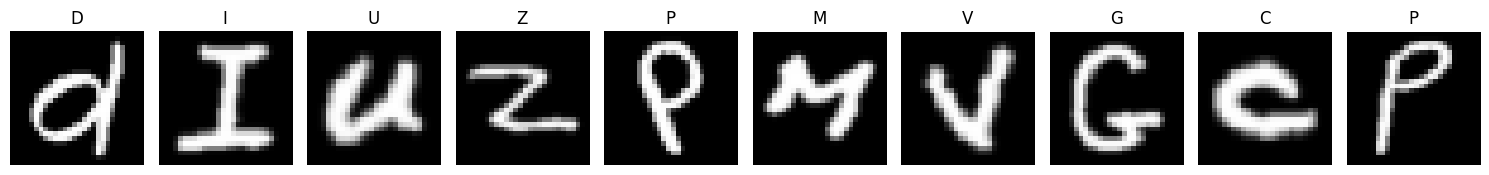

In [3]:
images, labels = next(iter(train_loader))
print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    img = images[i].squeeze().T
    letter = chr(labels[i].item() - 1 + ord("A"))

    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(letter)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 4. Mô hình: EMNISTMLP

Một mô hình MLP tối giản: `Flatten -> Linear(784, 128) -> ReLU -> Linear(128, 26)`.

- `784 = 28 x 28`, kích thước ảnh sau khi làm phẳng (flatten).
- `26` là số lượng lớp chữ cái.

In [4]:
class EMNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 26),
        )

    def forward(self, images):
        return self.net(images)


model = EMNISTMLP().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

print(model)

EMNISTMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=26, bias=True)
  )
)


## 5. Các vòng lặp huấn luyện và đánh giá

- `train_one_epoch`: với mỗi batch, thực hiện `zero_grad` -> forward -> tính loss ->
  `backward` -> `step`, đồng thời tích lũy giá trị loss và số lượng dự đoán đúng.
- `evaluate`: thực hiện các bước ghi nhận tương tự nhưng **không cập nhật trọng số**
  (sử dụng `model.eval()` + `torch.no_grad()`).

Cả hai hàm đều trả về kết quả `(average_loss, accuracy)`.

In [5]:
def run_batches(model, loader, criterion, optimizer=None):
    """Shared loop for both training and evaluation.

    If `optimizer` is provided the model is put in train mode and its
    weights are updated; otherwise it runs in eval mode under `no_grad`.
    """
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss, total_correct, total_samples = 0.0, 0, 0
    context = torch.enable_grad() if is_training else torch.no_grad()

    with context:
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE) - 1  # letters are labeled 1..26

            if is_training:
                optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += images.size(0)

    return total_loss / total_samples, total_correct / total_samples


def train_one_epoch(model, loader, criterion, optimizer):
    return run_batches(model, loader, criterion, optimizer=optimizer)


def evaluate(model, loader, criterion):
    return run_batches(model, loader, criterion, optimizer=None)

## 6. Quá trình huấn luyện

Huấn luyện trong `EPOCHS` epoch. Mỗi epoch bao gồm một lượt duyệt qua `train_loader`,
sau đó là đánh giá trên `val_loader`; các giá trị loss/độ chính xác được lưu lại để
vẽ biểu đồ sau này và được in ra màn hình console.

In [6]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch}: "
        f"train loss={train_loss:.4f}, val loss={val_loss:.4f}, "
        f"train acc={train_acc:.4f}, val acc={val_acc:.4f}"
    )

Epoch 1: train loss=1.2334, val loss=0.8672, train acc=0.6631, val acc=0.7540
Epoch 2: train loss=0.7318, val loss=0.6605, train acc=0.7909, val acc=0.8078
Epoch 3: train loss=0.5755, val loss=0.5512, train acc=0.8336, val acc=0.8372
Epoch 4: train loss=0.4918, val loss=0.4888, train acc=0.8555, val acc=0.8543
Epoch 5: train loss=0.4393, val loss=0.4567, train acc=0.8689, val acc=0.8625


## 7. Kết quả & Đánh giá thử nghiệm

1. Vẽ các đường biểu diễn hàm mất mát (loss) và độ chính xác (accuracy) (tập huấn luyện so với tập kiểm định) đặt cạnh nhau.
2. Đánh giá mô hình đã huấn luyện trên tập dữ liệu kiểm tra (`test_loader`) đã được tách riêng.
3. Trực quan hóa 10 kết quả dự đoán trên tập kiểm tra (màu xanh lá = đúng, màu đỏ = sai).

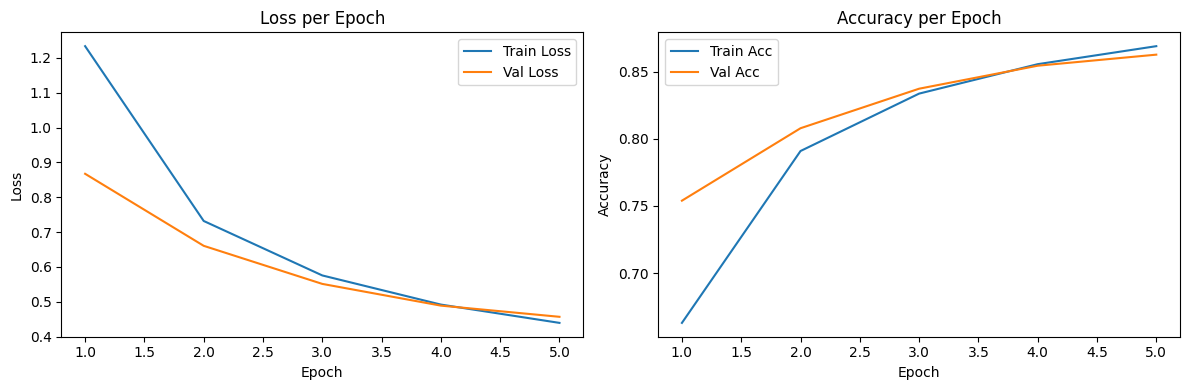

Test loss=0.4647, test accuracy=86.15%


In [7]:
epochs_range = range(1, EPOCHS + 1)
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

ax_loss.plot(epochs_range, train_losses, label="Train Loss")
ax_loss.plot(epochs_range, val_losses, label="Val Loss")
ax_loss.set_title("Loss per Epoch")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss")
ax_loss.legend()

ax_acc.plot(epochs_range, train_accuracies, label="Train Acc")
ax_acc.plot(epochs_range, val_accuracies, label="Val Acc")
ax_acc.set_title("Accuracy per Epoch")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy")
ax_acc.legend()

plt.tight_layout()
plt.show()

test_loss, test_accuracy = evaluate(model, test_loader, criterion)
print(f"Test loss={test_loss:.4f}, test accuracy={test_accuracy:.2%}")

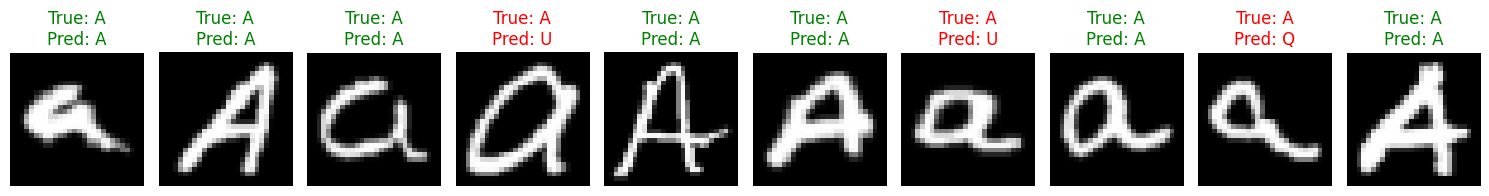

In [8]:
def letter_of(label_tensor_item):
    return chr(int(label_tensor_item) + ord("A"))


sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images.to(DEVICE)
sample_labels_adj = sample_labels.to(DEVICE) - 1

model.eval()
with torch.no_grad():
    preds = model(sample_images).argmax(dim=1)

fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i in range(10):
    img = sample_images[i].cpu().squeeze().T
    true_letter = letter_of(sample_labels_adj[i].item())
    pred_letter = letter_of(preds[i].item())
    color = "green" if true_letter == pred_letter else "red"

    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"True: {true_letter}\nPred: {pred_letter}", color=color)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 8. Lưu mô hình

Lưu các trọng số đã được huấn luyện (`state_dict`) để có thể tải lại mô hình sau này.

In [9]:
MODEL_PATH = "emnist_mlp.pt"
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model weights saved to '{MODEL_PATH}'")

Model weights saved to 'emnist_mlp.pt'
